In [1]:
%load_ext autoreload
%autoreload 2
from corti.bezier_multirotor_planning import derive_bezier7, derive_bezier3
from corti.TimeOptBez import find_opt_multirotor_time

import numpy as np

from cyecca.models.bezier import derive_ref, derive_eulerB321_to_quat, derive_multirotor
from cyecca.lie import SO3EulerB321, SO3Quat
import casadi as ca
from cyecca.models.rdd2 import (
    derive_position_control,
    derive_attitude_control,
    derive_attitude_rate_control,
)
from cyecca.models.rdd2_loglinear import (
    derive_se23_error,
    derive_outerloop_control,
    derive_so3_attitude_control,
)
from cyecca.models.rdd2 import derive_control_allocation
from cyecca.models.quadrotor import derive_model, sim

python:  /bin/python3
python:  /bin/python3


In [2]:
f = derive_control_allocation()["f_alloc"]
f_euler_to_quat = derive_eulerB321_to_quat()["eulerB321_to_quat"]
f_att_rate_control = derive_attitude_rate_control()["attitude_rate_control"]
f_multirotor = derive_multirotor()["bezier_multirotor"]
f_se23_error = derive_se23_error()["se23_error"]
f_se23_control = derive_outerloop_control()["se23_control"]
f_so3_control = derive_so3_attitude_control()["so3_attitude_control"]
f_ref = derive_ref()["f_ref"]
model = derive_model()

In [3]:
bezier7 = derive_bezier7()
bezier3 = derive_bezier3()
dt = 1e-2

# bezier boundary conditions
bc_t = np.array(
    [
        [  # position
            [0, 0, 0],  # wp0, x, y, z
            [0, 0, 2],  # wp0, x, y, z
            [0, -5, 2],
            [5, -5, 2],
            [5, 0, 2],
            [0, 0, 2],
            [0, 0, 2],
            [0, 0, 2],
            [0, 0, 2],
            [0, 0, 2],
            [0, 0, 2],
        ],
        [  # velocity
            [0, 0, 0],  # wp0, x, y, z
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
        ],
        [  # accel
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],  # wp0, x, y, z
        ],
        [  # jerk
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],  # wp0, x, y, z
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
        ],
    ]
)
bc_psi_list = np.array(
    [
        [  # attitude
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
        ],
        [  # angular velocity
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
            [0, 0, 0],
        ],
    ]
)

# solve for bezier trajectories
k = 10
T0_list = []
PX_list = []
PY_list = []
PZ_list = []
Ppsi_list = []
for i in range(bc_t.shape[1] - 1):
    bc = bc_t[:, i : i + 2, :]
    bc_psi = bc_psi_list[:, i : i + 2, :]
    T0 = 20  # find_opt_multirotor_time(8, 4, bc, bc_psi, k, 1)[0]
    PX = np.array(bezier7["bezier7_solve"](bc[:, 0, 0], bc[:, 1, 0], T0)).reshape(-1)
    PY = np.array(bezier7["bezier7_solve"](bc[:, 0, 1], bc[:, 1, 1], T0)).reshape(-1)
    PZ = np.array(bezier7["bezier7_solve"](bc[:, 0, 2], bc[:, 1, 2], T0)).reshape(-1)
    Ppsi = np.array(
        bezier3["bezier3_solve"](bc_psi[:, 0, 2], bc_psi[:, 1, 2], T0)
    ).reshape(-1)
    T0_list.append(T0)
    PX_list.append(PX)
    PY_list.append(PY)
    PZ_list.append(PZ)
    Ppsi_list.append(Ppsi)

# generate trajectory
x_list = []
y_list = []
z_list = []
vx_list = []
vy_list = []
vz_list = []
ax_list = []
ay_list = []
az_list = []
jx_list = []
jy_list = []
jz_list = []
sx_list = []
sy_list = []
sz_list = []
psi_list = []
dpsi_list = []
ddpsi_list = []
t_list = []
omega1_list = []
omega2_list = []
omega3_list = []
for leg in range(len(T0_list)):
    n_t = 100
    t_leg = np.array([np.arange(0, T0_list[leg], dt)])
    traj_x = np.array(bezier7["bezier7_traj"](t_leg, T0_list[leg], PX_list[leg])).T
    traj_y = np.array(bezier7["bezier7_traj"](t_leg, T0_list[leg], PY_list[leg])).T
    traj_z = np.array(bezier7["bezier7_traj"](t_leg, T0_list[leg], PZ_list[leg])).T
    traj_psi = np.array(bezier3["bezier3_traj"](t_leg, T0_list[leg], Ppsi_list[leg])).T
    x = traj_x[:, 0]
    y = traj_y[:, 0]
    z = traj_z[:, 0]
    vx = traj_x[:, 1]
    vy = traj_y[:, 1]
    vz = traj_z[:, 1]
    ax = traj_x[:, 2]
    ay = traj_y[:, 2]
    az = traj_z[:, 2]
    jx = traj_x[:, 3]
    jy = traj_y[:, 3]
    jz = traj_z[:, 3]
    sx = traj_x[:, 4]
    sy = traj_y[:, 4]
    sz = traj_z[:, 4]
    psi = traj_psi[:, 0]
    dpsi = traj_psi[:, 1]
    ddpsi = traj_psi[:, 2]
    for j in range(x.shape[0]):
        [omega, q_sp, omega_ff, _, M_ff, thrust_ff] = f_ref(
            psi[j], dpsi[j], ddpsi[j], np.array([vx[j], vy[j], vz[j]]).reshape(3,), 
            np.array([ax[j], ay[j], az[j]]).reshape(3,), np.array([jx[j], jy[j], jz[j]]).reshape(3,), np.array([sx[j], sy[j], sz[j]]).reshape(3,)
        )
        omega = np.array(omega).reshape(3,)
        omega1_list.append(omega[0])
        omega2_list.append(omega[1])
        omega3_list.append(omega[2])
    t = t_leg + leg * T0
    t_list.extend(t.reshape(-1))
    x_list.extend(x)
    y_list.extend(y)
    z_list.extend(z)
    vx_list.extend(vx)
    vy_list.extend(vy)
    vz_list.extend(vz)
    ax_list.extend(ax)
    ay_list.extend(ay)
    az_list.extend(az)
    jx_list.extend(jx)
    jy_list.extend(jy)
    jz_list.extend(jz)
    sx_list.extend(sx)
    sy_list.extend(sy)
    sz_list.extend(sz)
    psi_list.extend(psi)
    dpsi_list.extend(dpsi)
    ddpsi_list.extend(ddpsi)

In [4]:
# loglinear
model = derive_model()
x0_dict = model["x0_defaults"]
x0 = None
p = None
if x0 is not None:
    for k in x0.keys():
        if not k in x0_dict.keys():
            raise KeyError(k)
        x0_dict[k] = x0[k]
p_dict = model["p_defaults"]
if p is not None:
    for k in p.keys():
        if not k in p_dict.keys():
            raise KeyError(k)
        p_dict[k] = p[k]
x = np.array(list(x0_dict.values()), dtype=float)
p = np.array(list(p_dict.values()), dtype=float)
u = np.zeros(4, dtype=float)
t1 = 0
k_p_att = np.array([5, 5, 2], dtype=float)
leg = 0
CT = 8.54858e-06

thrust_trim = 2 * 9.8
# attitude rate
kp = np.array([0.3, 0.3, 0.05], dtype=float)
ki = np.array([0, 0, 0], dtype=float)
kd = np.array([0.0, 0.0, 0], dtype=float)
i0 = 0
e0 = np.zeros(3, dtype=float)  # error for attitude rate loop
de0 = np.zeros(3, dtype=float)  # deriv of att error (for lowpass)
f_cut = 10.0
i_max = np.array([0, 0, 0], dtype=float)
dae = model["dae"]
z_i = 0
pos_list = []
u_alloc_list = []
M_ff_list = []
thrust_ff_list = []
x_sp_list = []
y_sp_list = []
z_sp_list = []
v_sp_list = []
a_sp_list = []
j_sp_list = []
s_sp_list = []
motor_omega_list = []
t1_list = []
zeta_list = []
for i in range(len(t_list)):
    t = t_list[i]
    if t > T0 * (leg + 1):
        leg += 1
    t_bezier = t - T0 * leg - dt / 2
    pw = np.array(
        [
            x[model["x_index"]["position_op_w_0"]],
            x[model["x_index"]["position_op_w_1"]],
            x[model["x_index"]["position_op_w_2"]],
        ]
    )
    vw = np.array(
        [
            x[model["x_index"]["velocity_w_p_b_0"]],
            x[model["x_index"]["velocity_w_p_b_1"]],
            x[model["x_index"]["velocity_w_p_b_2"]],
        ]
    )
    q = np.array(
        [
            x[model["x_index"]["quaternion_wb_0"]],
            x[model["x_index"]["quaternion_wb_1"]],
            x[model["x_index"]["quaternion_wb_2"]],
            x[model["x_index"]["quaternion_wb_3"]],
        ]
    )
    omega = np.array(
        [
            x[model["x_index"]["omega_wb_b_0"]],
            x[model["x_index"]["omega_wb_b_1"]],
            x[model["x_index"]["omega_wb_b_2"]],
        ]
    )
    [
        x_sp,
        y_sp,
        z_sp,
        psi_sp,
        dpsi_sp,
        ddpsi_sp,
        vw_sp,
        aw_sp,
        jw_sp,
        sw_sp,
    ] = f_multirotor(
        t_bezier, T0, PX_list[leg], PY_list[leg], PZ_list[leg], Ppsi_list[leg]
    )
    [_, q_sp, omega_ff, _, M_ff, thrust_ff] = f_ref(
        psi_sp, dpsi_sp, ddpsi_sp, vw_sp, aw_sp, jw_sp, sw_sp
    )
    qc_sp = f_euler_to_quat(psi_sp, 0, 0)
    pw_sp = np.array([x_sp, y_sp, z_sp]).reshape(-1)
    zeta = f_se23_error(
        pw,
        vw,
        q,
        pw_sp,
        vw_sp,
        q_sp,
    )
    # position control: world frame
    [thrust, z_i, omega_fb, q_sp] = f_se23_control(
        thrust_trim,
        k_p_att,
        zeta,
        aw_sp,
        q,
        z_i,
        dt,
    )
    omega_fb = f_so3_control(k_p_att, q, q_sp)
    omega_sp = omega_fb + omega_ff
    M_fb, i1, e1, de1, alpha = f_att_rate_control(
        kp,
        ki,
        kd,
        f_cut,
        i_max,
        omega,
        omega_sp,
        i0,
        e0,
        de0,
        dt,
    )
    i0 = i1
    e0 = e1
    de0 = de1
    M_sp = M_fb + M_ff
    u, Fp, Fm, Ft, Msat = f(100, 0.25 / ca.sqrt(2), 0.016, CT, thrust, M_sp)
    try:
        f_int = ca.integrator("test", "cvodes", dae, t, t + dt)
        res = f_int(x0=x, z0=0, p=p, u=u)
    except RuntimeError as e:
        print(e)
        xdot = model["f"](x=x, u=u, p=p)
        print(xdot, x, u, p)
        raise e
    t1 += dt
    x = np.array(res["xf"]).reshape(-1)
    res["p"] = p_dict
    pos = x[0:3]
    pos_list.append(np.array(pos).reshape(-1))
    u_alloc_list.append(np.array(u).reshape(-1))
    M_ff_list.append(np.array(M_ff).reshape(-1))
    thrust_ff_list.append(np.array(thrust_ff).reshape(-1))
    zeta_list.append(np.array(zeta).reshape(-1))
# res["yf"] = model["g"](res["xf"], u, p_dict.values())

for k in ["xf", "zf"]:
    res[k] = np.array(res[k])

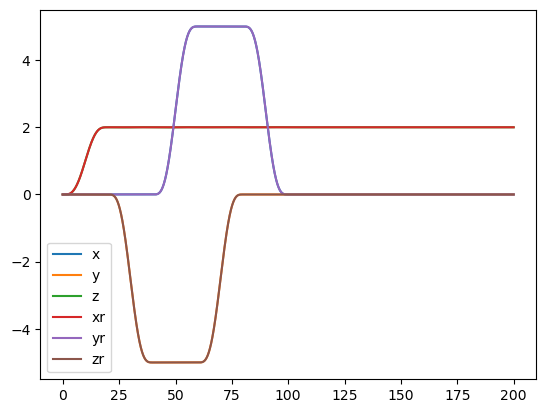

In [5]:
import matplotlib.pyplot as plt

t = np.arange(0, t_list[-1] + dt, dt)
plt.plot(t, np.array(pos_list)[:, 0])
plt.plot(t, np.array(pos_list)[:, 1])
plt.plot(t, np.array(pos_list)[:, 2])

plt.plot(t, z_list)
plt.plot(t, x_list)
plt.plot(t, y_list)
plt.legend(["x", "y", "z", "xr", "yr", "zr"])

0.0996387363689339
0.09963952169005531
0.24440125830717643


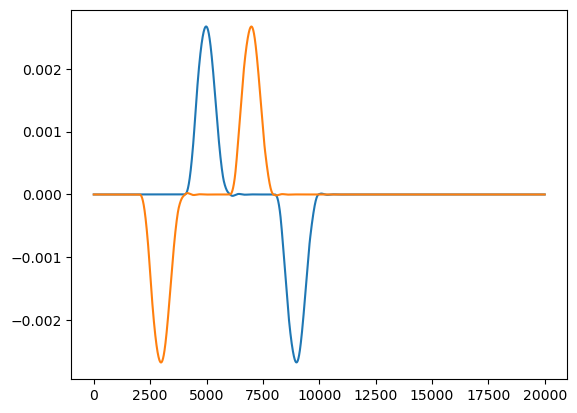

In [6]:
plt.plot(np.array(pos_list)[:, 0] - x_list)
plt.plot(np.array(pos_list)[:, 1] - y_list)
# plt.plot(np.array(pos_list)[:, 2]-z_list)
print(np.linalg.norm(np.array(pos_list)[:, 0] - x_list))
print(np.linalg.norm(np.array(pos_list)[:, 1] - y_list))
print(np.linalg.norm(np.array(pos_list)[:, 2] - z_list))

In [16]:
%load_ext autoreload
%autoreload 2
from lie.SE23 import *
from flowpipe.inner_bound import *
from flowpipe.outer_bound import *
from flowpipe.flowpipe import *
from sim.multirotor_control import *
from sim.multirotor_plan import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
ax = [np.max(ax_list)]
ay = [np.max(ay_list)]
az = [np.min(az_list)-9.8]
omega1 = [np.max(omega1_list)]
omega2 = [np.max(omega2_list)]
omega3 = [np.max(omega3_list)]

In [18]:
# Set disturbance here
w1 = 0.1 # disturbance for translational (impact a)
w2 = 0.01 # disturbance for angular (impact alpha)

In [19]:
# solve LMI
sol = find_omega_invariant_set(omega1, omega2, omega3) 

# Initial condition
P = sol['P']
e0 = np.array([0,0,0]) # initial error
beta = (e0.T@P@e0) # initial Lyapnov value

# find bound
omegabound = omega_bound(omega1, omega2, omega3, w2, beta) # result for inner bound
print(omegabound)

0.0031622776623733795


In [33]:
# solve LMI
sol_LMI = find_se23_invariant_set(ax, ay, az, omega1, omega2, omega3)

0.4
optimal


In [34]:
# Initial condition
e = np.array([0,0,0,0,0,0,0,0,0]) # initial error in Lie group (nonlinear)

# transfer initial error to Lie algebra (linear)
e0 = ca.DM(SE23Dcm.vee(SE23Dcm.log(SE23Dcm.matrix(e))))
e0 = np.array([e0]).reshape(9,)
ebeta = e0.T@sol_LMI['P']@e0

# find invairant set points in Lie algebra (linear)
points, val = se23_invariant_set_points(sol_LMI, 20, w2, thetabound, ebeta)
points_theta, val = se23_invariant_set_points_theta(sol_LMI, 20, w2, thetabound, ebeta)

In [35]:
# map invariant set points to Lie group (nonlinear)
inv_points = exp_map(points, points_theta)

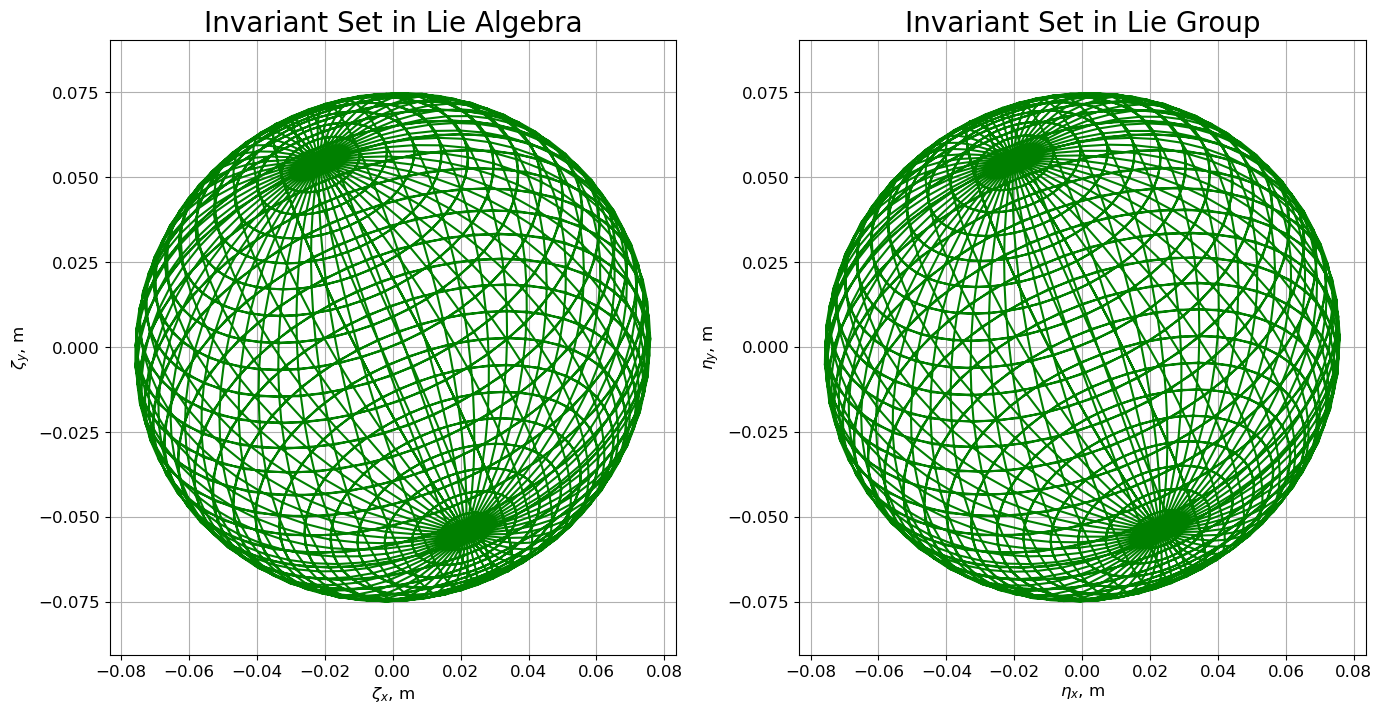

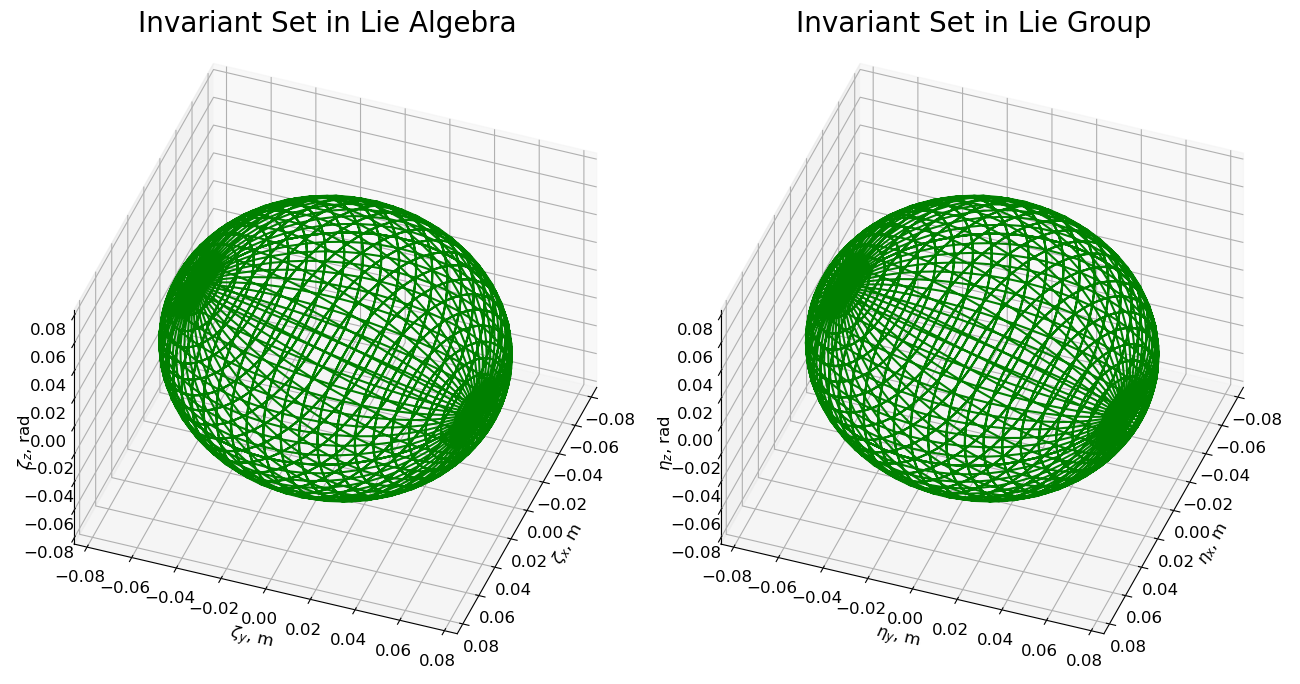

In [36]:
plt.figure(figsize=(14,7))
plt.rcParams.update({'font.size': 12})
ax1 = plt.subplot(121)
ax1.plot(points[0, :], points[1, :], 'g', label='with Dynamic Inversion')
# ax.plot(pointscl[0, :], pointscl[1, :], 'b', linewidth=0.5, label='without Dynamic Inversion')
ax1.set_xlabel('$\\zeta_x$, m')
ax1.set_ylabel('$\\zeta_y$, m')
# ax.plot(xopt.x,xopt.y,'ro')
plt.axis('equal')
plt.grid(True)
# plt.legend(loc=1)
ax2 = plt.subplot(122)
ax2.plot(inv_points[0, :-1], inv_points[1, :-1], 'g', label='with Dynamic Inversion')
# ax2.plot(inv_pointscl[0, :-1], inv_pointscl[1, :-1], 'b', linewidth=0.5, label='without Dynamic Inversion')
# ax2.plot(e[0],e[1],'ro')
ax2.set_xlabel('$\\eta_x$, m')
ax2.set_ylabel('$\\eta_y$, m')
plt.grid(True)
# plt.legend(loc=1)
plt.axis('equal')
plt.tight_layout()
ax1.set_title('Invariant Set in Lie Algebra', fontsize=20)
ax2.set_title('Invariant Set in Lie Group', fontsize=20)
# plt.savefig('figures/Invariant_l.eps', format='eps', bbox_inches='tight')

plt.figure(figsize=(14,7))
ax1 = plt.subplot(121, projection='3d', proj_type='ortho', elev=40, azim=20)
# ax.plot3D(e0[0], e0[1], e0[2], 'ro');
ax1.plot3D(points[0, :], points[1, :], points[2, :],'g', label='with Dynamic Inversion')
# ax.plot3D(pointscl[0, :], pointscl[1, :], pointscl[2, :],'b', linewidth=0.5, label='without Dynamic Inversion')
ax1.set_xlabel('$\\zeta_x$, m')
ax1.set_ylabel('$\\zeta_y$, m')
ax1.set_zlabel('$\\zeta_z$, rad', labelpad=1)
ax1.set_title('Invariant Set in Lie Algebra', fontsize=20)
# plt.subplots_adjust(left=9, right=10, top=0.5, bottom=0.08)
# plt.tight_layout()
plt.axis('auto')
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)
# plt.legend(loc=1)
ax2 = plt.subplot(122, projection='3d', proj_type='ortho', elev=40, azim=20)
# ax2.plot3D(e[0], e[1], e[2], 'ro');
ax2.plot3D(inv_points[0, :], inv_points[1, :], inv_points[2, :], 'g', label='with Dynamic Inversion')
# ax2.plot3D(inv_pointscl[0, :], inv_pointscl[1, :], inv_pointscl[2, :], 'b', linewidth=0.5, label='without Dynamic Inversion')
# ax2.plot3D(e[0], e[1], e[2], 'ro');
ax2.set_xlabel('$\\eta_x$, m')
ax2.set_ylabel('$\\eta_y$, m')
ax2.set_zlabel('$\\eta_z$, rad')
ax2.set_title('Invariant Set in Lie Group', fontsize=20)
plt.axis('auto')
plt.subplots_adjust(left=0.45, right=1, top=0.5, bottom=0.08)
# plt.legend(loc=1)
plt.tight_layout()
# plt.savefig('figures/Invariant3d_l.eps', format='eps', bbox_inches='tight')